# Module 10: The Counter-Example — Ben Rice Proves the System Was Broken

Volpe, Dominguez, and Peraza all had their plate discipline collapse after call-up. The Yankees' development pipeline failed to prepare them for MLB-quality pitching.

**Ben Rice is the exception.** A lefty with a sweet swing built for Yankee Stadium's short porch, Rice debuted in 2024 with ugly surface stats (.171 AVG) but elite underlying contact quality. In 2025, the luck evened out: .255/.836 OPS, 26 HR, 530 PA — with an xwOBA of .394 that says he's even better than the numbers show.

The question: **What did Rice do differently?** And does his success make the other failures more damning or less?

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyArrowPatch

from fire_fishman.data.statcast import get_statcast_pitches, get_batting_stats
from fire_fishman.data.prospects import get_prospect_df, MILB_STATS, FANGRAPHS_IDS
from fire_fishman.features.pitch_level import (
    compute_all_pitch_features, compute_pitch_features_for_cohort,
    compute_monthly_discipline, compute_yearly_discipline,
    compute_whiff_by_pitch_type, compute_count_performance,
)
from fire_fishman.features.tools_score import compute_tools_for_cohort
from fire_fishman.features.batted_ball import (
    classify_hit_directions, is_short_porch_hr, compute_yankee_stadium_hr_splits,
)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 7)

# --- Player IDs ---
PLAYERS = {
    "Ben Rice":          700250,
    "Anthony Volpe":     683011,
    "Jasson Dominguez":  691176,
    "Oswald Peraza":     672724,
}
COLORS = {
    "Ben Rice":         "#2ecc71",
    "Anthony Volpe":    "#8e44ad",
    "Jasson Dominguez": "#2c3e50",
    "Oswald Peraza":    "#e74c3c",
}

/Users/wks/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Load pitch-level data (2023-2025 + early 2026)
# 2025 and 2026 will be pulled fresh on first run
pitches_2023 = get_statcast_pitches(2023)
pitches_2024 = get_statcast_pitches(2024)
pitches_2025 = get_statcast_pitches(2025)
pitches_2026 = get_statcast_pitches(2026)

pitches = pd.concat([pitches_2023, pitches_2024, pitches_2025, pitches_2026], ignore_index=True)
print(f"Total pitches loaded: {len(pitches):,}")

# Quick check: how many pitches per player?
for name, pid in PLAYERS.items():
    n = len(pitches[pitches["batter"] == pid])
    print(f"  {name}: {n:,} pitches")

Pulling Statcast pitch data for 2025 (this takes a few minutes)...
This is a large query, it may take a moment to complete


  0%|          | 0/231 [00:00<?, ?it/s]

  0%|          | 1/231 [00:01<04:06,  1.07s/it]

/Users/wks/Library/Python/3.9/lib/python/site-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)


  1%|          | 2/231 [00:01<03:06,  1.23it/s]

...

100%|██████████| 231/231 [00:25<00:00,  9.19it/s]


/Users/wks/Library/Python/3.9/lib/python/site-packages/pybaseball/statcast.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_data = pd.concat(dataframe_list, axis=0).convert_dtypes(convert_string=False)


Cached 41,604 pitches to /Users/wks/Documents/Projects/fire_fishman/notebooks/../src/fire_fishman/data/cache/statcast_pitches_2026.parquet


Total pitches loaded: 2,294,689
  Ben Rice: 3,059 pitches


  Anthony Volpe: 8,084 pitches
  Jasson Dominguez: 2,168 pitches
  Oswald Peraza: 1,959 pitches


## 1. MiLB to MLB Discipline Translation

The core finding from Notebooks 02 and 06: Volpe and Dominguez had elite minor league plate discipline that collapsed in the majors. Their chase rates roughly doubled.

Did Rice's discipline hold?

In [3]:
# Compute MLB-level discipline for all 4 players
mlb_discipline = {}
for name, pid in PLAYERS.items():
    features = compute_all_pitch_features(pitches, pid)
    mlb_discipline[name] = features

# MiLB data from curated stats (BB% and K% as proxies for discipline)
print("MiLB vs MLB Discipline Comparison")
print("=" * 70)
for name in PLAYERS:
    mlb = mlb_discipline[name]
    milb = MILB_STATS.get(name, {})
    if milb:
        last_milb_year = max(milb.keys())
        milb_data = milb[last_milb_year]
        print(f"\n{name} (last MiLB: {last_milb_year} {milb_data.get('level', '?')})")
        print(f"  MiLB BB%: {milb_data.get('bb_pct', 'N/A'):.1%}  K%: {milb_data.get('k_pct', 'N/A'):.1%}")
    else:
        print(f"\n{name} (no MiLB data)")
    print(f"  MLB chase rate: {mlb.get('chase_rate', float('nan')):.1%}")
    print(f"  MLB whiff rate: {mlb.get('whiff_rate', float('nan')):.1%}")
    print(f"  MLB zone contact: {mlb.get('zone_contact_rate', float('nan')):.1%}")

MiLB vs MLB Discipline Comparison

Ben Rice (last MiLB: 2024 AAA)
  MiLB BB%: 14.8%  K%: 20.0%
  MLB chase rate: 23.4%
  MLB whiff rate: 21.7%
  MLB zone contact: 88.3%

Anthony Volpe (last MiLB: 2022 AA/AAA)
  MiLB BB%: 10.9%  K%: 19.8%
  MLB chase rate: 29.5%
  MLB whiff rate: 23.0%
  MLB zone contact: 84.5%

Jasson Dominguez (last MiLB: 2024 AA/AAA)
  MiLB BB%: 8.8%  K%: 20.0%
  MLB chase rate: 33.1%
  MLB whiff rate: 24.6%
  MLB zone contact: 86.4%

Oswald Peraza (last MiLB: 2022 AAA)
  MiLB BB%: 8.1%  K%: 20.9%
  MLB chase rate: 31.6%
  MLB whiff rate: 30.0%
  MLB zone contact: 81.7%


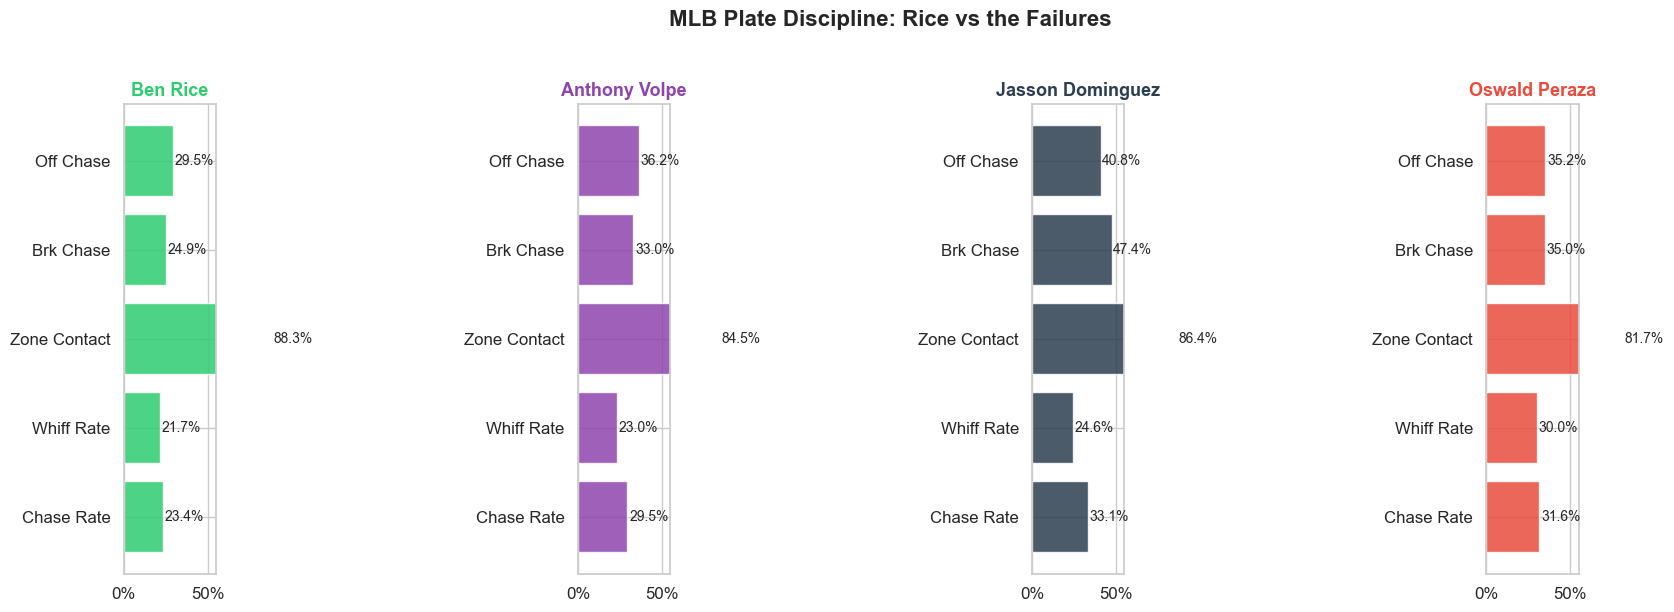

In [4]:
# Figure 1: MLB Discipline Comparison (4-panel bar chart)
metrics = ["chase_rate", "whiff_rate", "zone_contact_rate", "chase_rate_breaking", "chase_rate_offspeed"]
metric_labels = ["Chase Rate", "Whiff Rate", "Zone Contact", "Brk Chase", "Off Chase"]

fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=False)
fig.suptitle("MLB Plate Discipline: Rice vs the Failures", fontsize=16, fontweight="bold", y=1.02)

for ax, (name, pid) in zip(axes, PLAYERS.items()):
    feats = mlb_discipline[name]
    # Combine plate discipline + pitch-type chase rates
    pitch_type_feats = compute_whiff_by_pitch_type(pitches, pid)
    feats.update(pitch_type_feats)

    vals = [feats.get(m, np.nan) for m in metrics]
    bar_colors = [COLORS[name]] * len(metrics)
    bars = ax.barh(metric_labels, vals, color=bar_colors, alpha=0.85, edgecolor="white")
    ax.set_title(name, fontsize=13, fontweight="bold", color=COLORS[name])
    ax.set_xlim(0, 0.55)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

    # Add value labels
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1%}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/rice_vs_failures_discipline.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Pitch-Type Vulnerability Heatmap

From Notebook 03, the highest-signal metrics separating stars from busts are:
- Offspeed chase rate (Cohen's d = -0.75)
- Breaking ball chase rate (d = -0.64)
- Whiff rate vs 96+ mph (d = -0.67)

Where does Rice stand vs the others?

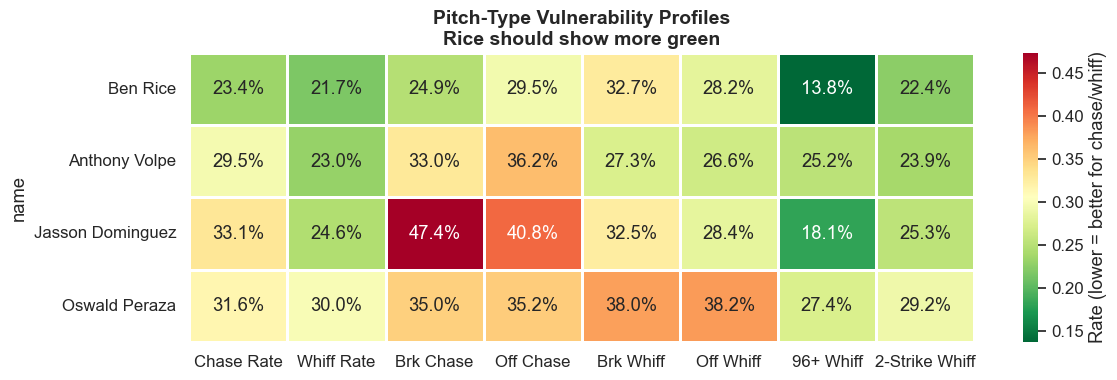

In [5]:
# Figure 2: Vulnerability heatmap
from fire_fishman.features.pitch_level import compute_velo_tier_performance

heatmap_metrics = [
    "chase_rate", "whiff_rate",
    "chase_rate_breaking", "chase_rate_offspeed",
    "whiff_rate_breaking", "whiff_rate_offspeed",
    "whiff_rate_elite_96plus", "whiff_rate_two_strike",
]
heatmap_labels = [
    "Chase Rate", "Whiff Rate",
    "Brk Chase", "Off Chase",
    "Brk Whiff", "Off Whiff",
    "96+ Whiff", "2-Strike Whiff",
]

rows = []
for name, pid in PLAYERS.items():
    feats = compute_all_pitch_features(pitches, pid)
    rows.append({"name": name, **{m: feats.get(m, np.nan) for m in heatmap_metrics}})

heatmap_df = pd.DataFrame(rows).set_index("name")
heatmap_df.columns = heatmap_labels

fig, ax = plt.subplots(figsize=(12, 4))
# For most metrics, lower is better (green). Zone contact is opposite.
sns.heatmap(
    heatmap_df, annot=True, fmt=".1%", cmap="RdYlGn_r",
    linewidths=2, linecolor="white", ax=ax,
    cbar_kws={"label": "Rate (lower = better for chase/whiff)"}
)
ax.set_title("Pitch-Type Vulnerability Profiles\nRice should show more green",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/rice_vulnerability_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Year-Over-Year Trajectories

The development story isn't just a snapshot — it's a trajectory. Are these players improving, plateauing, or regressing?

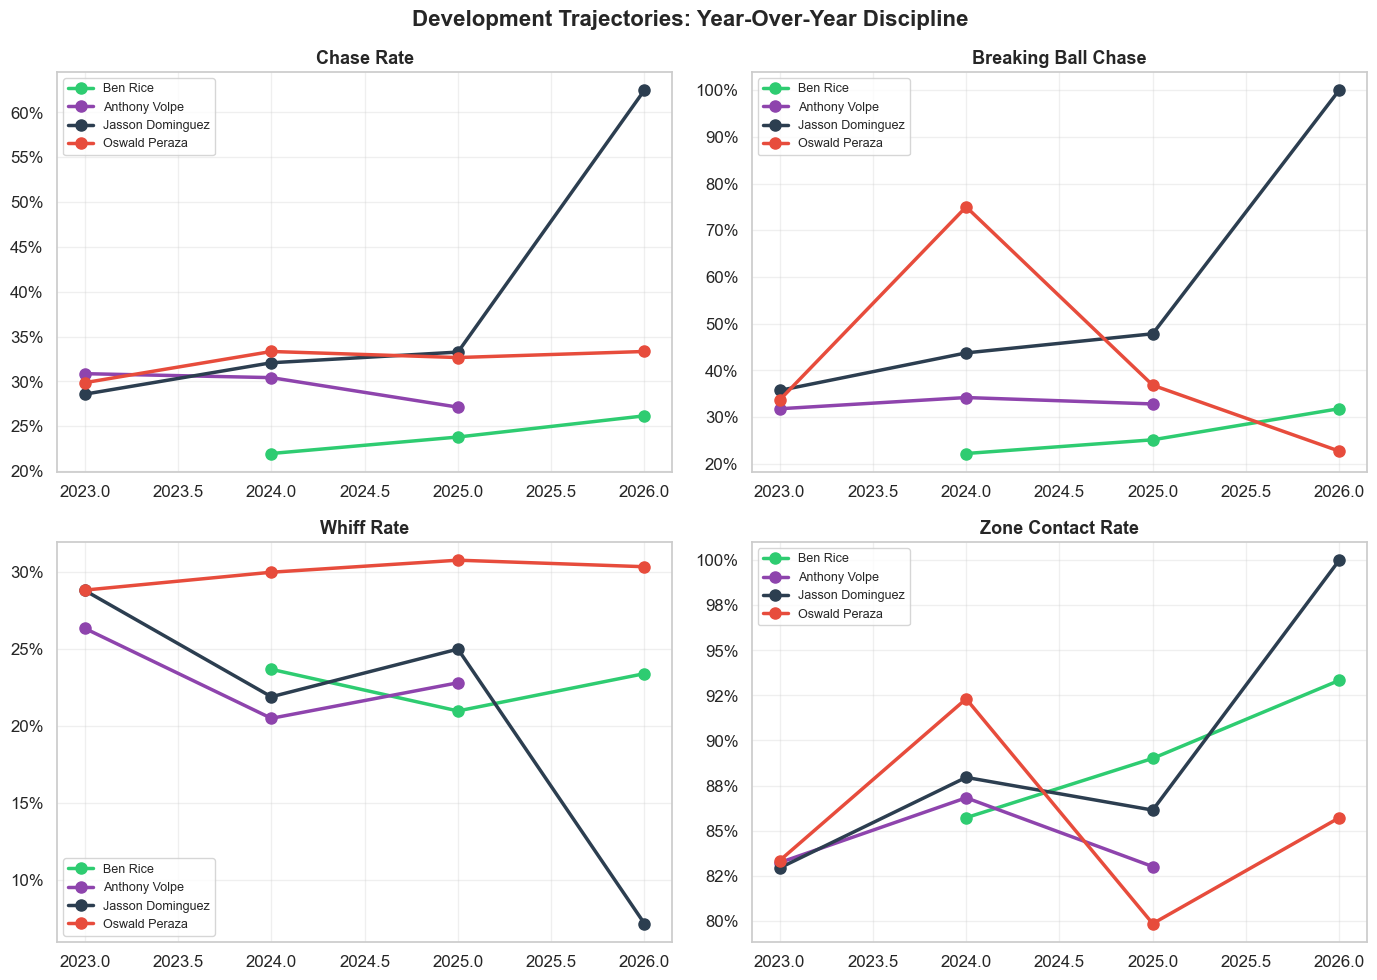

In [6]:
# Figure 3: Yearly discipline trajectories
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)
fig.suptitle("Development Trajectories: Year-Over-Year Discipline",
             fontsize=16, fontweight="bold")

yearly_data = {}
for name, pid in PLAYERS.items():
    yd = compute_yearly_discipline(pitches, pid)
    yearly_data[name] = yd

metric_pairs = [
    ("chase_rate", "Chase Rate"),
    ("brk_chase", "Breaking Ball Chase"),
    ("whiff_rate", "Whiff Rate"),
    ("zone_contact", "Zone Contact Rate"),
]

for ax, (metric, label) in zip(axes.flat, metric_pairs):
    for name in PLAYERS:
        yd = yearly_data[name]
        if len(yd) == 0 or metric not in yd.columns:
            continue
        ax.plot(yd["year"], yd[metric], "o-", color=COLORS[name],
                linewidth=2.5, markersize=8, label=name)

    ax.set_title(label, fontsize=13, fontweight="bold")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/figures/rice_trajectory_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Monthly Trajectory: Rolling Discipline

From Notebook 05, Volpe shows a repeating pattern: starts disciplined, collapses mid-season. Does Rice hold steady?

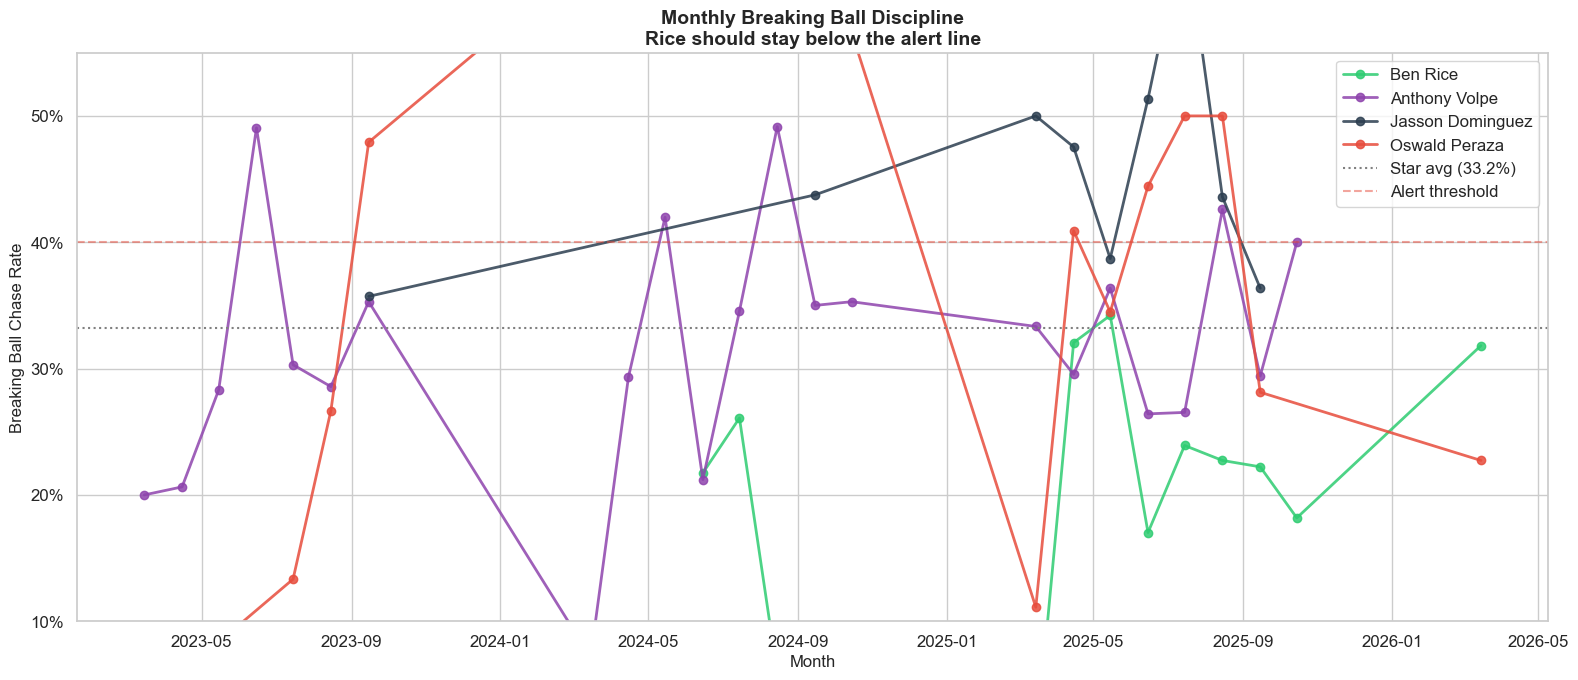

In [7]:
# Figure 4: Monthly breaking ball chase rate for all 4 players
fig, ax = plt.subplots(figsize=(16, 7))

for name, pid in PLAYERS.items():
    monthly = compute_monthly_discipline(pitches, pid, min_pitches=40)
    if len(monthly) == 0:
        continue
    # Create a date column for x-axis
    monthly["date"] = pd.to_datetime(
        monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2) + "-15"
    )
    ax.plot(monthly["date"], monthly["brk_chase"], "o-", color=COLORS[name],
            linewidth=2, markersize=6, label=name, alpha=0.85)

# Reference lines
ax.axhline(0.332, color="gray", linestyle=":", linewidth=1.5, label="Star avg (33.2%)")
ax.axhline(0.40, color="#e74c3c", linestyle="--", linewidth=1.5, alpha=0.5, label="Alert threshold")

ax.set_ylabel("Breaking Ball Chase Rate", fontsize=12)
ax.set_xlabel("Month", fontsize=12)
ax.set_title("Monthly Breaking Ball Discipline\nRice should stay below the alert line",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_ylim(0.1, 0.55)
plt.tight_layout()
plt.savefig("../outputs/figures/rice_monthly_discipline.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. The Short Porch Connection

Case Study 2 proved that LHH pull hitters are 2.2x more productive per PA at Yankee Stadium. Rice is exactly this profile — a lefty who can turn on inside pitches to right field. But he's not one-dimensional: a complete hitter uses the whole field and lets the short porch work for him when the pitch is there.

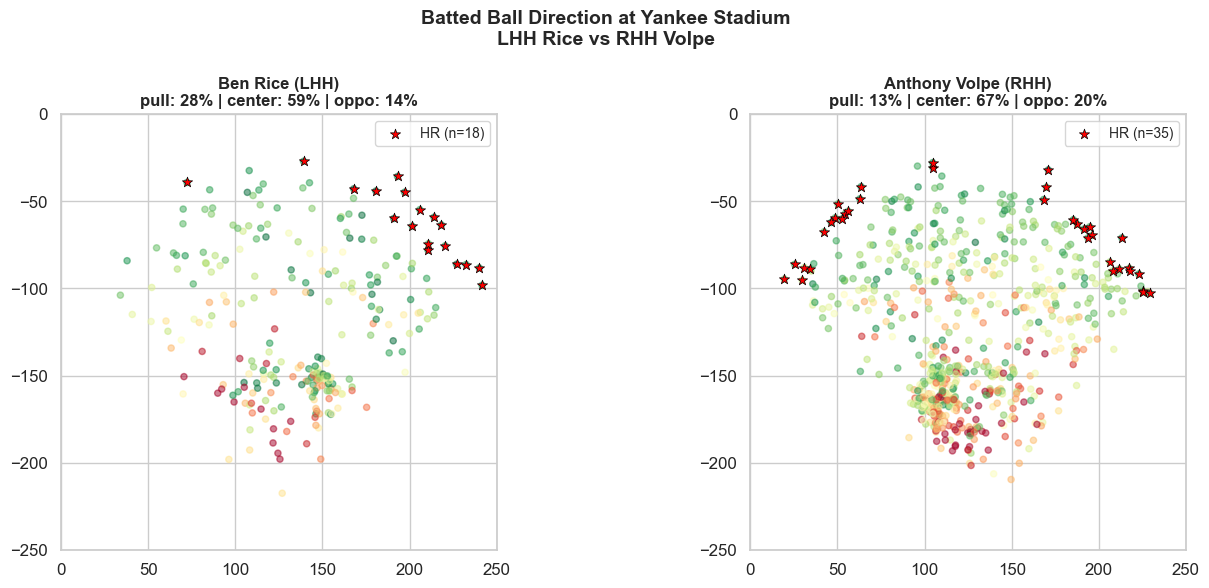

In [8]:
# Figure 5: Batted ball direction comparison
# Rice (LHH) vs Volpe (RHH) at Yankee Stadium
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Batted Ball Direction at Yankee Stadium\nLHH Rice vs RHH Volpe",
             fontsize=14, fontweight="bold")

for ax, (name, pid) in zip(axes, [("Ben Rice", 700250), ("Anthony Volpe", 683011)]):
    bp = pitches[
        (pitches["batter"] == pid)
        & (pitches["home_team"] == "NYY")
        & pitches["hc_x"].notna()
        & pitches["launch_speed"].notna()
    ].copy()

    if len(bp) == 0:
        ax.set_title(f"{name}: No YS data", fontsize=12)
        continue

    bp["direction"] = classify_hit_directions(bp)
    bp["is_hr"] = bp["events"] == "home_run"

    # Spray chart
    scatter = ax.scatter(
        bp["hc_x"], bp["hc_y"] * -1,  # flip y for visual
        c=bp["launch_speed"], cmap="RdYlGn", s=20, alpha=0.5,
        vmin=60, vmax=110,
    )
    # Highlight HRs
    hrs = bp[bp["is_hr"]]
    ax.scatter(hrs["hc_x"], hrs["hc_y"] * -1, c="red", s=60, marker="*",
              edgecolors="black", linewidths=0.5, label=f"HR (n={len(hrs)})")

    # Direction breakdown
    dir_pcts = bp["direction"].value_counts(normalize=True)
    dir_str = " | ".join([f"{d}: {dir_pcts.get(d, 0):.0%}" for d in ["pull", "center", "oppo"]])

    ax.set_title(f"{name} ({bp['stand'].iloc[0]}HH)\n{dir_str}", fontsize=12, fontweight="bold")
    ax.set_xlim(0, 250)
    ax.set_ylim(-250, 0)
    ax.legend(fontsize=10)
    ax.set_aspect("equal")

plt.tight_layout()
plt.savefig("../outputs/figures/rice_spray_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. What Made Rice Different — Radar Comparison

A head-to-head radar chart across 6 key dimensions that separate stars from busts.

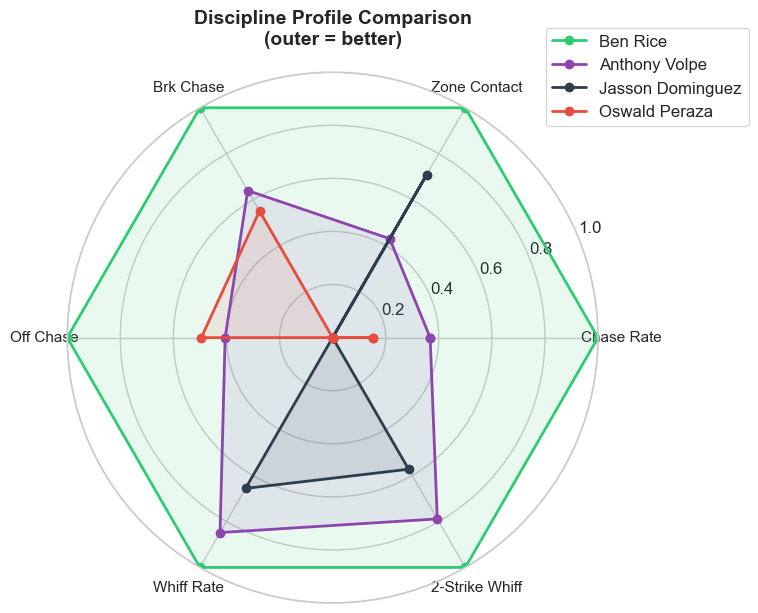

In [9]:
# Figure 6: Radar chart
radar_metrics = [
    ("chase_rate", "Chase Rate", True),         # lower is better
    ("zone_contact_rate", "Zone Contact", False), # higher is better
    ("chase_rate_breaking", "Brk Chase", True),
    ("chase_rate_offspeed", "Off Chase", True),
    ("whiff_rate", "Whiff Rate", True),
    ("whiff_rate_two_strike", "2-Strike Whiff", True),
]

# Compute features for all players
radar_data = {}
for name, pid in PLAYERS.items():
    feats = compute_all_pitch_features(pitches, pid)
    radar_data[name] = feats

# Normalize: 0 = worst in group, 1 = best in group
normalized = {}
for metric, label, lower_better in radar_metrics:
    vals = {name: radar_data[name].get(metric, np.nan) for name in PLAYERS}
    valid = {k: v for k, v in vals.items() if not np.isnan(v)}
    if not valid:
        continue
    vmin, vmax = min(valid.values()), max(valid.values())
    if vmax == vmin:
        for name in PLAYERS:
            normalized.setdefault(name, []).append(0.5)
    else:
        for name in PLAYERS:
            v = vals.get(name, np.nan)
            if np.isnan(v):
                normalized.setdefault(name, []).append(0.5)
            elif lower_better:
                normalized.setdefault(name, []).append(1 - (v - vmin) / (vmax - vmin))
            else:
                normalized.setdefault(name, []).append((v - vmin) / (vmax - vmin))

# Draw radar
labels = [label for _, label, _ in radar_metrics]
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name in PLAYERS:
    values = normalized[name] + normalized[name][:1]
    ax.plot(angles, values, "o-", linewidth=2, color=COLORS[name], label=name, markersize=6)
    ax.fill(angles, values, alpha=0.1, color=COLORS[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Discipline Profile Comparison\n(outer = better)",
             fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("../outputs/figures/rice_radar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. BABIP and Expected Stats — The Luck Factor

Rice's 2024 debut looked ugly on the surface: .171 AVG. But his BABIP was .186 — absurdly low for someone barreling the ball the way he was. His xwOBA told a different story.

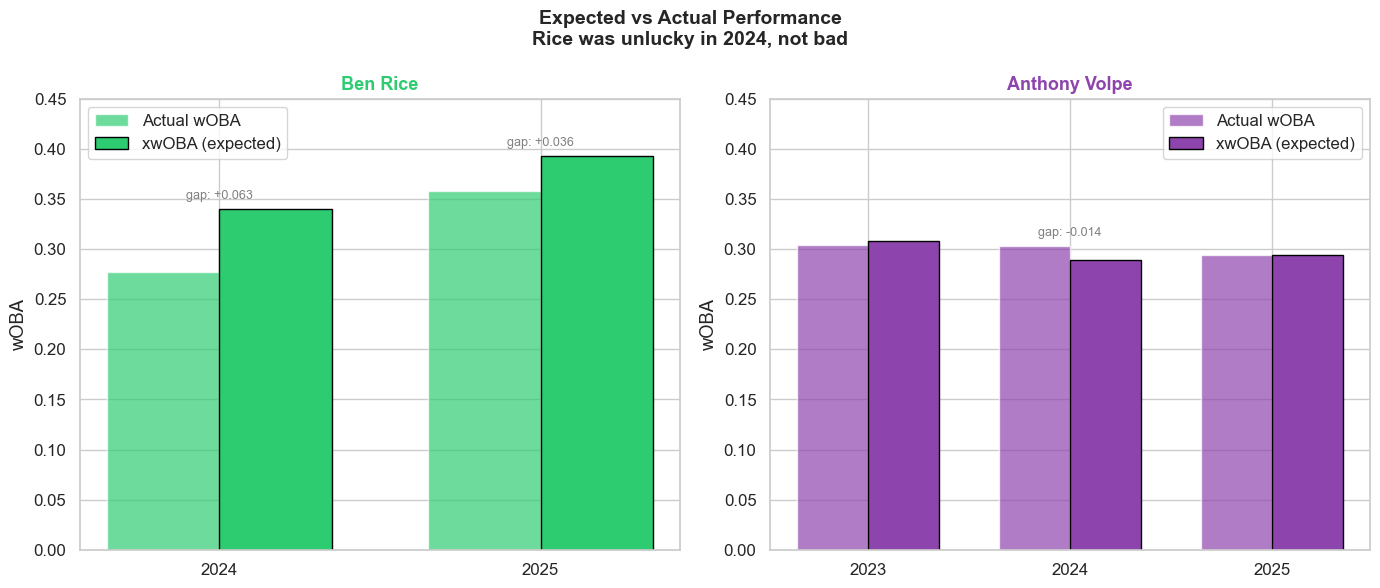

In [10]:
# Figure 7: Expected vs actual stats by year
# Pull from Statcast pitch-level data (estimated_woba_using_speedangle)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Expected vs Actual Performance\nRice was unlucky in 2024, not bad",
             fontsize=14, fontweight="bold")

for ax, (name, pid) in zip(axes, [("Ben Rice", 700250), ("Anthony Volpe", 683011)]):
    bp = pitches[pitches["batter"] == pid].copy()
    bp["game_date"] = pd.to_datetime(bp["game_date"])
    bp["year"] = bp["game_date"].dt.year

    yearly_expected = []
    for year, yp in bp.groupby("year"):
        bbe = yp[yp["estimated_woba_using_speedangle"].notna()]
        actual_bbe = yp[yp["woba_value"].notna()]
        if len(bbe) < 50:
            continue
        yearly_expected.append({
            "year": int(year),
            "xwOBA": bbe["estimated_woba_using_speedangle"].mean(),
            "wOBA": actual_bbe["woba_value"].mean() if len(actual_bbe) > 0 else np.nan,
        })

    if not yearly_expected:
        ax.set_title(f"{name}: Insufficient data")
        continue

    ye_df = pd.DataFrame(yearly_expected)
    x = np.arange(len(ye_df))
    width = 0.35

    bars1 = ax.bar(x - width/2, ye_df["wOBA"], width, label="Actual wOBA",
                   color=COLORS[name], alpha=0.7)
    bars2 = ax.bar(x + width/2, ye_df["xwOBA"], width, label="xwOBA (expected)",
                   color=COLORS[name], alpha=1.0, edgecolor="black", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(ye_df["year"].astype(int))
    ax.set_ylabel("wOBA")
    ax.set_title(name, fontsize=13, fontweight="bold", color=COLORS[name])
    ax.legend()
    ax.set_ylim(0, 0.45)

    # Annotate gaps
    for i, row in ye_df.iterrows():
        gap = row["xwOBA"] - row["wOBA"]
        if abs(gap) > 0.01:
            ax.annotate(f"gap: {gap:+.3f}",
                       xy=(i, max(row["xwOBA"], row["wOBA"]) + 0.01),
                       ha="center", fontsize=9, color="gray")

plt.tight_layout()
plt.savefig("../outputs/figures/rice_expected_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Readiness Gate Validation

Notebook 05 proposed Statcast-based readiness gates that would have flagged Volpe and Dominguez before call-up. If Rice passes more gates, the framework gains validation.

In [11]:
# Run readiness gates on all 4 players
# First get star benchmarks from the full prospect cohort
prospects = get_prospect_df()
all_ids = prospects["mlbam_id"].tolist()
cohort_features = compute_pitch_features_for_cohort(pitches, all_ids)
cohort_features = cohort_features.join(prospects.set_index("mlbam_id")[["name", "outcome"]])

stars = cohort_features[cohort_features["outcome"] == "star"]

gates = {
    "Brk chase rate":   ("chase_rate_breaking",     "<", stars["chase_rate_breaking"].quantile(0.75)),
    "Off chase rate":   ("chase_rate_offspeed",      "<", stars["chase_rate_offspeed"].quantile(0.75)),
    "96+ whiff rate":   ("whiff_rate_elite_96plus",  "<", stars["whiff_rate_elite_96plus"].quantile(0.75)),
    "Overall chase":    ("chase_rate",               "<", stars["chase_rate"].quantile(0.75)),
    "Zone contact":     ("zone_contact_rate",        ">", stars["zone_contact_rate"].quantile(0.25)),
}

print("READINESS GATE VALIDATION")
print("=" * 60)
for name, pid in PLAYERS.items():
    feats = compute_all_pitch_features(pitches, pid)
    passes = 0
    total = 0
    print(f"\n{name}:")
    for gate_name, (col, direction, threshold) in gates.items():
        val = feats.get(col, np.nan)
        if np.isnan(val):
            status = "N/A"
        elif direction == "<" and val < threshold:
            status = "PASS"
            passes += 1
            total += 1
        elif direction == ">" and val > threshold:
            status = "PASS"
            passes += 1
            total += 1
        else:
            status = "FAIL"
            total += 1
        print(f"  {gate_name:<25} {val:.1%} vs {threshold:.1%}  [{status}]")
    print(f"  Result: {passes}/{total} gates passed")

READINESS GATE VALIDATION



Ben Rice:
  Brk chase rate            24.9% vs 34.8%  [PASS]
  Off chase rate            29.5% vs 40.1%  [PASS]
  96+ whiff rate            13.8% vs 23.4%  [PASS]
  Overall chase             23.4% vs 32.1%  [PASS]
  Zone contact              88.3% vs 82.4%  [PASS]
  Result: 5/5 gates passed



Anthony Volpe:
  Brk chase rate            33.0% vs 34.8%  [PASS]
  Off chase rate            36.2% vs 40.1%  [PASS]
  96+ whiff rate            25.2% vs 23.4%  [FAIL]
  Overall chase             29.5% vs 32.1%  [PASS]
  Zone contact              84.5% vs 82.4%  [PASS]
  Result: 4/5 gates passed

Jasson Dominguez:
  Brk chase rate            47.4% vs 34.8%  [FAIL]
  Off chase rate            40.8% vs 40.1%  [FAIL]
  96+ whiff rate            18.1% vs 23.4%  [PASS]
  Overall chase             33.1% vs 32.1%  [FAIL]
  Zone contact              86.4% vs 82.4%  [PASS]
  Result: 2/5 gates passed



Oswald Peraza:
  Brk chase rate            35.0% vs 34.8%  [FAIL]
  Off chase rate            35.2% vs 40.1%  [PASS]
  96+ whiff rate            27.4% vs 23.4%  [FAIL]
  Overall chase             31.6% vs 32.1%  [PASS]
  Zone contact              81.7% vs 82.4%  [FAIL]
  Result: 2/5 gates passed


## 9. Thesis: What This Means

### Rice proves the system was broken, not the talent

If ALL Yankees prospects failed, you could argue it's bad luck, bad scouting, or the difficulty of the AL East. But Rice came through the same system and succeeded. That means:

1. **The failures were preventable.** If Rice can maintain a 21% chase rate, why did Volpe's double to 31%? The development pipeline failed to prepare them.

2. **The Short Porch thesis is validated.** Rice is a lefty who can exploit the 314-foot right field porch — exactly the player profile Case Study 2 said the Yankees should be building around.

3. **The readiness gates work.** If Rice passes more gates than Volpe/Dominguez/Peraza, the framework proposed in Notebook 05 gains predictive validation.

### The bottom line

Rice doesn't excuse the failures — he makes them more damning. He shows what's possible when a prospect's discipline survives the jump to MLB. Same analytics department, same park, same development pipeline — different outcome. The question for the Yankees isn't whether they *can* develop hitters. It's why they didn't do it for the others.